## Pronóstico de demanda eléctrica diaria en Gran Buenos Aires mediante modelos ARIMA, SARIMA y SARIMAX

##### Autores: Jorge Adrián Alvarez, Nahuel Elias de la Paz Otonelo Canale.

### Análisis de Series de Tiempo 
### Especialización en Inteligencia Artificial -- FIUBA

### DATA SET: Comportamiento de la Demanda de Energía Eléctrica en el MEM 

(MEM: Mercado Eléctrico Mayorista)

Información Estadística Histórica Enero 2017 a Abril 2026 obtenido de el sitio oficial de CAMMESA https://cammesaweb.cammesa.com/2026/06/12/covid-19-comportamiento-de-la-demanda-de-energia-electrica-en-el-mem/




Acompañando a la información y análisis de los datos operativos de corto plazo en relación al comportamiento de la demanda, se pone a disposición distintas bases de los datos DEMANDA NETA DIARIA a nivel de Total País, por Región, y detallando la demanda de los Grandes Usuarios Mayoristas (GUMA), agrupados en Ramas y Actividades características. 

En detalle cada hoja contiene:
- Hoja Base Datos Región => Seguimiento de la demanda neta diaria por región eléctrica
- Hoja Base Datos Tipo Usuario => Seguimiento de la demanda neta diaria de los Distribuidores y Grandes Usuarios del MEM, dividiendo entre por rama y región.
- Hoja Datos GUMAs Actividad => Seguimiento de la demanda neta diaria de los Grandes Usuarios del MEM, dividiendo por rama y actividad.


A diferencia de la información operativa, la demanda es NETA en estas bases de datos, los resultados se encuentran consolidados de acuerdo a las mediciones que se obtienen del sistema de medición comercial (SMEC) y utilizados para realizar la transacción económica de cada agente demandante.

**En este trabajo el análisis se enfoca en la serie de demanda de energía eléctrica diaria de la la región de Gran Buenos Aires (GBA).** Esto incluye a GUMAs y a usuarios residenciales.


<img src="imagenes/amba_mapa.jpg" width="400" alt="Mapa del gran Buenos Aires">

In [1]:
from pathlib import Path

import pandas as pd

archivo = Path("data") / "Base_Demanda_Diaria_2017_2026.xlsx"
hoja = "Datos_Region"

df_data_region = pd.read_excel(archivo, sheet_name=hoja)
df_data_region.head(10)

,DEMANDA NETA POR REGIÓN,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,UNIDAD MW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BASE TRANSACCIÓNES ECONÓMICAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AÑO,MES,Fecha,Tipo día,GRAN BS.AS.,BUENOS AIRES,CENTRO,LITORAL,CUYO,NOROESTE,NORESTE,COMAHUE,PATAGONICA,DEMANDA TOTAL,TEMPERATURA REFERENCIA MEDIA GBA °C
4,2017,2017-01-01 00:00:00,2017-01-01 00:00:00,Domingo o Feriado,6352.695208,1472.2705,1134.39425,1766.623958,903.135875,1602.126625,1400.333417,561.243208,500.863042,15693.686083,31.3
5,2017,2017-01-01 00:00:00,2017-01-02 00:00:00,Lunes habiles,6617.86375,1779.435208,1363.527292,1963.925833,1091.811167,1627.56725,1585.616708,638.835167,540.57775,17209.160125,25.35
6,2017,2017-01-01 00:00:00,2017-01-03 00:00:00,Martes Habiles,6677.996167,1888.984333,1600.744625,2036.345917,1178.718583,1806.474,1652.989833,624.649083,536.472333,18003.374875,25.45
7,2017,2017-01-01 00:00:00,2017-01-04 00:00:00,Miercoles habiles,6426.997625,1840.623833,1356.381292,1756.6405,1078.90325,1759.855667,1604.750375,598.4005,528.904083,16951.457125,27
8,2017,2017-01-01 00:00:00,2017-01-05 00:00:00,Jueves Habiles,5873.95075,1770.942583,1366.018917,1848.409375,1037.791833,1403.490042,1228.303125,585.206708,524.657125,15638.770458,21.9
9,2017,2017-01-01 00:00:00,2017-01-06 00:00:00,Viernes habiles,5781.113583,1801.103708,1367.353708,1929.803917,1135.512667,1354.617292,1218.666875,615.4865,550.862542,15754.520792,24.3


In [2]:
columnas = df_data_region.iloc[3]
columnas_validas = columnas.notna()

# Se toman los encabezados desde la fila 3 del DataFrame original.
df_data_region = df_data_region.loc[4:, columnas_validas].copy()
df_data_region.columns = columnas[columnas_validas]
df_data_region = df_data_region.reset_index(drop=True)

# Se normalizan mes y fecha para conservar solo sus componentes numéricos.
df_data_region["MES"] = pd.to_datetime(df_data_region["MES"], errors="coerce").dt.month.astype("Int64")
df_data_region["Fecha"] = pd.to_datetime(df_data_region["Fecha"], errors="coerce").dt.day.astype("Int64")
df_data_region["AÑO"] = pd.to_numeric(df_data_region["AÑO"], errors="coerce").astype("Int64")

df_data_region.head()


3,AÑO,MES,Fecha,Tipo día,GRAN BS.AS.,BUENOS AIRES,CENTRO,LITORAL,CUYO,NOROESTE,NORESTE,COMAHUE,PATAGONICA,DEMANDA TOTAL,TEMPERATURA REFERENCIA MEDIA GBA °C
0,2017,1,1,Domingo o Feriado,6352.695208,1472.2705,1134.39425,1766.623958,903.135875,1602.126625,1400.333417,561.243208,500.863042,15693.686083,31.3
1,2017,1,2,Lunes habiles,6617.86375,1779.435208,1363.527292,1963.925833,1091.811167,1627.56725,1585.616708,638.835167,540.57775,17209.160125,25.35
2,2017,1,3,Martes Habiles,6677.996167,1888.984333,1600.744625,2036.345917,1178.718583,1806.474,1652.989833,624.649083,536.472333,18003.374875,25.45
3,2017,1,4,Miercoles habiles,6426.997625,1840.623833,1356.381292,1756.6405,1078.90325,1759.855667,1604.750375,598.4005,528.904083,16951.457125,27
4,2017,1,5,Jueves Habiles,5873.95075,1770.942583,1366.018917,1848.409375,1037.791833,1403.490042,1228.303125,585.206708,524.657125,15638.770458,21.9


### Construcción del data frame, EDA y visualización.

In [3]:
partes_fecha = df_data_region[["AÑO", "MES", "Fecha"]].astype("Int64")
fecha = pd.to_datetime(
    {
        "year": partes_fecha["AÑO"],
        "month": partes_fecha["MES"],
        "day": partes_fecha["Fecha"],
    },
    errors="coerce",
)

# Se construye una fecha real a partir de año, mes y día.
demanda_gbsas = pd.DataFrame(
    {
        "fecha": fecha,
        "demanda": pd.to_numeric(df_data_region["GRAN BS.AS."], errors="coerce"),
        "temp_media": pd.to_numeric(
            df_data_region["TEMPERATURA REFERENCIA MEDIA GBA °C"], errors="coerce"
        ),
    }
)

demanda_gbsas.head()


,fecha,demanda,temp_media
0,2017-01-01,6352.695208,31.30
1,2017-01-02,6617.863750,25.35
2,2017-01-03,6677.996167,25.45
3,2017-01-04,6426.997625,27.00
4,2017-01-05,5873.950750,21.90


In [4]:
eda_demanda_gbsas = demanda_gbsas.sort_values("fecha").reset_index(drop=True)

# Se resume la cantidad de valores faltantes por variable.
faltantes = eda_demanda_gbsas.isna().sum().rename("faltantes").to_frame()

# Se revisa la frecuencia temporal a partir de fechas consecutivas.
frecuencia = (
    eda_demanda_gbsas["fecha"]
    .dropna()
    .diff()
    .value_counts()
    .rename_axis("salto")
    .reset_index(name="cantidad")
)

# Se identifican outliers con el criterio intercuartílico.
def resumir_outliers(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    mascara = serie.lt(lim_inf) | serie.gt(lim_sup)

    return pd.Series(
        {
            "lim_inf": lim_inf,
            "lim_sup": lim_sup,
            "cantidad_outliers": int(mascara.sum()),
        }
    )

resumen_outliers = pd.DataFrame(
    {
        columna: resumir_outliers(eda_demanda_gbsas[columna].dropna())
        for columna in ["demanda", "temp_media"]
    }
).T

mascara_outliers = (
    eda_demanda_gbsas["demanda"].lt(resumen_outliers.loc["demanda", "lim_inf"])
    | eda_demanda_gbsas["demanda"].gt(resumen_outliers.loc["demanda", "lim_sup"])
    | eda_demanda_gbsas["temp_media"].lt(resumen_outliers.loc["temp_media", "lim_inf"])
    | eda_demanda_gbsas["temp_media"].gt(resumen_outliers.loc["temp_media", "lim_sup"])
)
detalle_outliers = eda_demanda_gbsas.loc[mascara_outliers].head(10)

display(faltantes)
display(frecuencia)
display(resumen_outliers)
detalle_outliers


,faltantes
fecha,0
demanda,0
temp_media,0


,salto,cantidad
0,1 days,3406


,lim_inf,lim_sup,cantidad_outliers
demanda,2937.909052,8591.631969,19.0
temp_media,0.925000,37.125000,0.0


,fecha,demanda,temp_media
1639,2021-06-28,8606.909000,7.70
1640,2021-06-29,8649.155750,7.75
1998,2022-06-22,8618.049833,7.45
2251,2023-03-02,8832.432250,31.55
2252,2023-03-03,8907.479625,30.40
2259,2023-03-10,8798.100500,31.40
2260,2023-03-11,8634.538208,32.20
2262,2023-03-13,9259.645625,31.00
2263,2023-03-14,9366.818083,32.30
2587,2024-02-01,8963.100000,31.50


Los outliers de consumo se dan en días con temperaturas medias muy altas o muy bajas, pareciera que no representan errores de carga o medición. Por el momento se mantienen. 

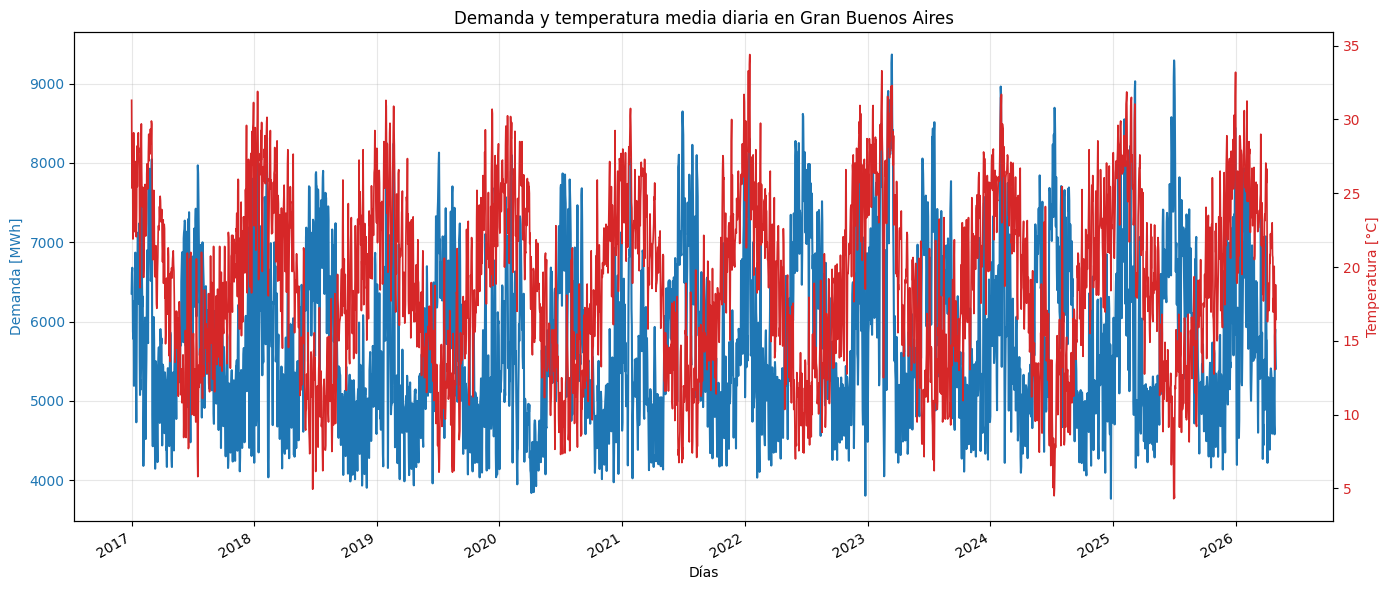

In [5]:
import matplotlib.pyplot as plt

# Se ordenan los datos para asegurar la secuencia temporal.
datos_grafico = demanda_gbsas.sort_values("fecha").dropna(subset=["fecha"])

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.plot(datos_grafico["fecha"], datos_grafico["demanda"], color="tab:blue", linewidth=1.5)
ax2.plot(datos_grafico["fecha"], datos_grafico["temp_media"], color="tab:red", linewidth=1.2)

# Se asignan etiquetas y unidades a cada eje vertical.
ax1.set_xlabel("Días")
ax1.set_ylabel("Demanda [MWh]", color="tab:blue")
ax2.set_ylabel("Temperatura [°C]", color="tab:red")
ax1.set_title("Demanda y temperatura media diaria en Gran Buenos Aires")

ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax1.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


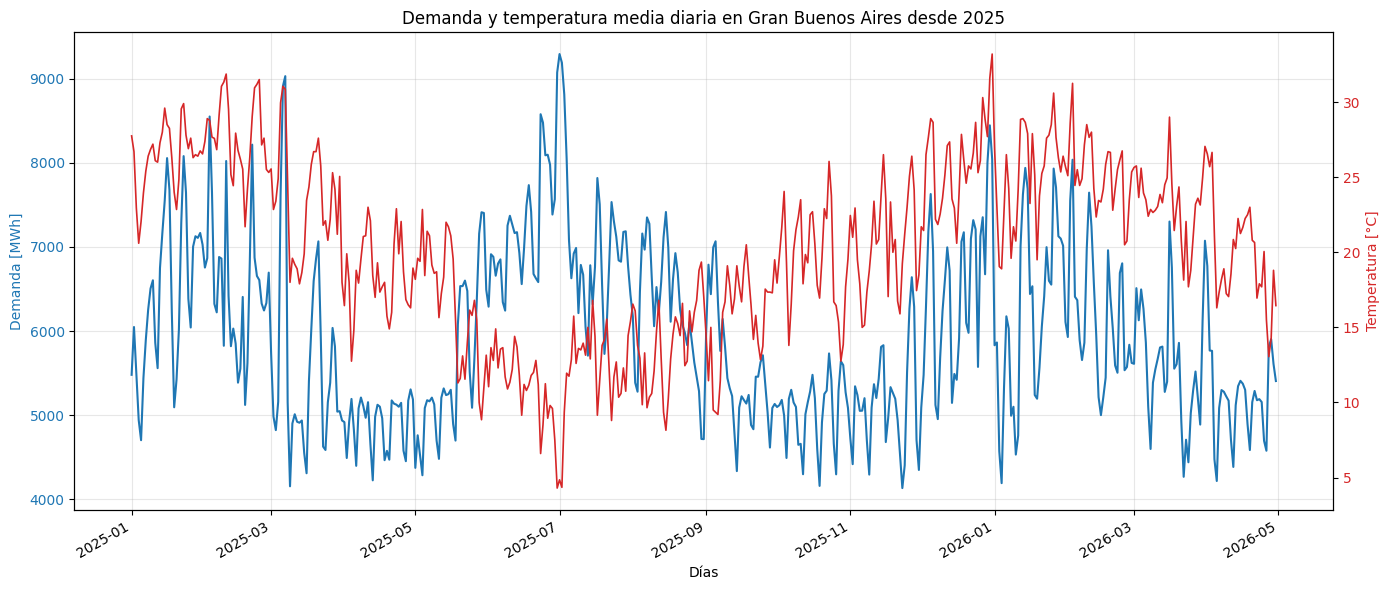

In [6]:
# Se filtran los datos desde enero de 2025 en adelante.
datos_grafico_2025 = demanda_gbsas.loc[
    demanda_gbsas["fecha"] >= pd.Timestamp("2025-01-01")
].sort_values("fecha")

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.plot(datos_grafico_2025["fecha"], datos_grafico_2025["demanda"], color="tab:blue", linewidth=1.5)
ax2.plot(datos_grafico_2025["fecha"], datos_grafico_2025["temp_media"], color="tab:red", linewidth=1.2)

# Se asignan etiquetas y unidades a cada eje vertical.
ax1.set_xlabel("Días")
ax1.set_ylabel("Demanda [MWh]", color="tab:blue")
ax2.set_ylabel("Temperatura [°C]", color="tab:red")
ax1.set_title("Demanda y temperatura media diaria en Gran Buenos Aires desde 2025")

ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax1.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### Impacto de la pandemia de COVID-19 en la demanda de energía (Gran Buenos Aires)

Durante el año 2020, la pandemia de COVID-19 y las consecuentes medidas de confinamiento (Aislamiento Social, Preventivo y Obligatorio - ASPO) alteraron significativamente las rutinas de la población: las personas permanecieron mayormente en sus hogares, cayeron las actividades industriales y comerciales presenciales, y se redujeron los traslados y el trabajo en oficinas.

Para evaluar este impacto sin alterar las variables originales de la serie temporal, realizamos un análisis exploratorio específico sobre el período 2019-2021 utilizando variables independientes (`df_analisis_pandemia` y `df_pandemia`).

**Recomendación de la Media Móvil y Relación con la Estacionalidad Semanal:**
La serie de demanda de energía eléctrica presenta una marcada **estacionalidad semanal** (un ciclo de 7 días, donde el consumo en días laborables es sustancialmente mayor que en los fines de semana). Si graficáramos los datos diarios directamente, el ruido causado por este comportamiento semanal impediría observar con claridad la tendencia de mediano plazo.

Para remover este ruido estacional de manera efectiva, se utiliza una **Media Móvil Simple (SMA) de 7 días**:
1. **Cancelación del ciclo estacional:** Al establecer una ventana de promedio móvil de exactamente 7 días (o múltiplos de 7), cada punto calculado de la media móvil contiene exactamente un lunes, un martes, un miércoles, un jueves, un viernes, un sábado y un domingo. Como la ventana siempre incluye exactamente un ciclo completo, el efecto del día de la semana se promedia y se **cancela matemáticamente**, dejando a la vista únicamente la tendencia subyacente y las fluctuaciones no semanales.
2. **Alineación temporal:** Usando una media móvil centrada (`center=True`), la estimación se alinea perfectamente con la fecha media del intervalo de 7 días, evitando desfasajes temporales en la visualización.


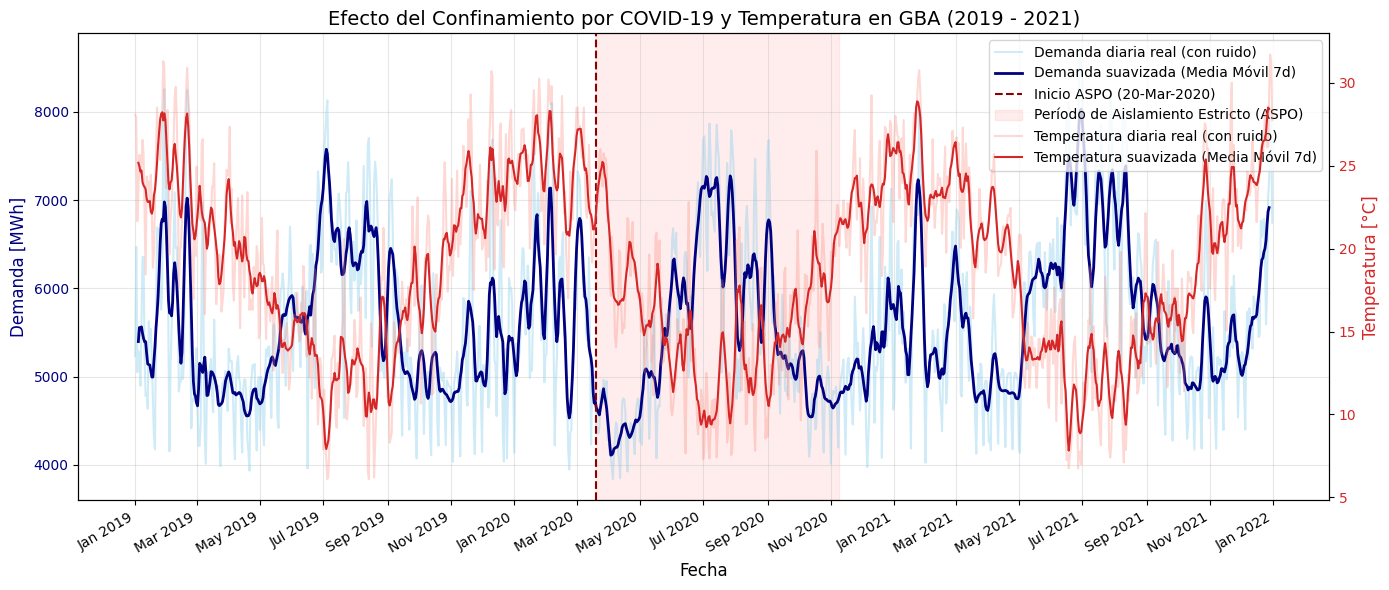

In [7]:
# Importaciones necesarias para el bloque
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Definición de nuevas variables independientes para evitar sobreescritura
df_analisis_pandemia = demanda_gbsas.copy()

# Filtramos el periodo 2019-2021 para observar prepandemia, cuarentena y recuperación
df_pandemia = df_analisis_pandemia[
    (df_analisis_pandemia["fecha"] >= "2019-01-01") & 
    (df_analisis_pandemia["fecha"] <= "2021-12-31")
].sort_values("fecha").copy()

# Cálculo de la media móvil de 7 días para demanda y temperatura
# El tamaño de ventana de 7 días elimina la estacionalidad semanal.
df_pandemia["demanda_ma7"] = df_pandemia["demanda"].rolling(window=7, center=True).mean()
df_pandemia["temp_ma7"] = df_pandemia["temp_media"].rolling(window=7, center=True).mean()

# Gráfico comparativo con doble eje Y
fig, ax1 = plt.subplots(figsize=(14, 6))

# Demanda en el eje principal (izquierdo)
ax1.plot(
    df_pandemia["fecha"], 
    df_pandemia["demanda"], 
    color="skyblue", 
    alpha=0.4, 
    label="Demanda diaria real (con ruido)"
)
ax1.plot(
    df_pandemia["fecha"], 
    df_pandemia["demanda_ma7"], 
    color="navy", 
    linewidth=2.0, 
    label="Demanda suavizada (Media Móvil 7d)"
)
ax1.set_ylabel("Demanda [MWh]", color="navy", fontsize=12)
ax1.tick_params(axis="y", labelcolor="navy")

# Temperatura en el eje secundario (derecho)
ax2 = ax1.twinx()
ax2.plot(
    df_pandemia["fecha"], 
    df_pandemia["temp_media"], 
    color="salmon", 
    alpha=0.3, 
    label="Temperatura diaria real (con ruido)"
)
ax2.plot(
    df_pandemia["fecha"], 
    df_pandemia["temp_ma7"], 
    color="tab:red", 
    linewidth=1.5, 
    label="Temperatura suavizada (Media Móvil 7d)"
)
ax2.set_ylabel("Temperatura [°C]", color="tab:red", fontsize=12)
ax2.tick_params(axis="y", labelcolor="tab:red")

# Hitos y fases de la cuarentena en Argentina
aspo_inicio = pd.Timestamp("2020-03-20")
dispo_inicio = pd.Timestamp("2020-11-09")

# Línea vertical para el inicio del confinamiento (ASPO)
ax1.axvline(x=aspo_inicio, color="darkred", linestyle="--", linewidth=1.5, label="Inicio ASPO (20-Mar-2020)")

# Sombreado del período de cuarentena estricta (ASPO)
ax1.axvspan(aspo_inicio, dispo_inicio, color="red", alpha=0.07, label="Período de Aislamiento Estricto (ASPO)")

# Combinar leyendas de ambos ejes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

# Configuración general del gráfico
ax1.set_title("Efecto del Confinamiento por COVID-19 y Temperatura en GBA (2019 - 2021)", fontsize=14)
ax1.set_xlabel("Fecha", fontsize=12)
ax1.grid(True, alpha=0.3)

# Formateo del eje X
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()


### Descomposición MSTL de la serie de demanda en GBA

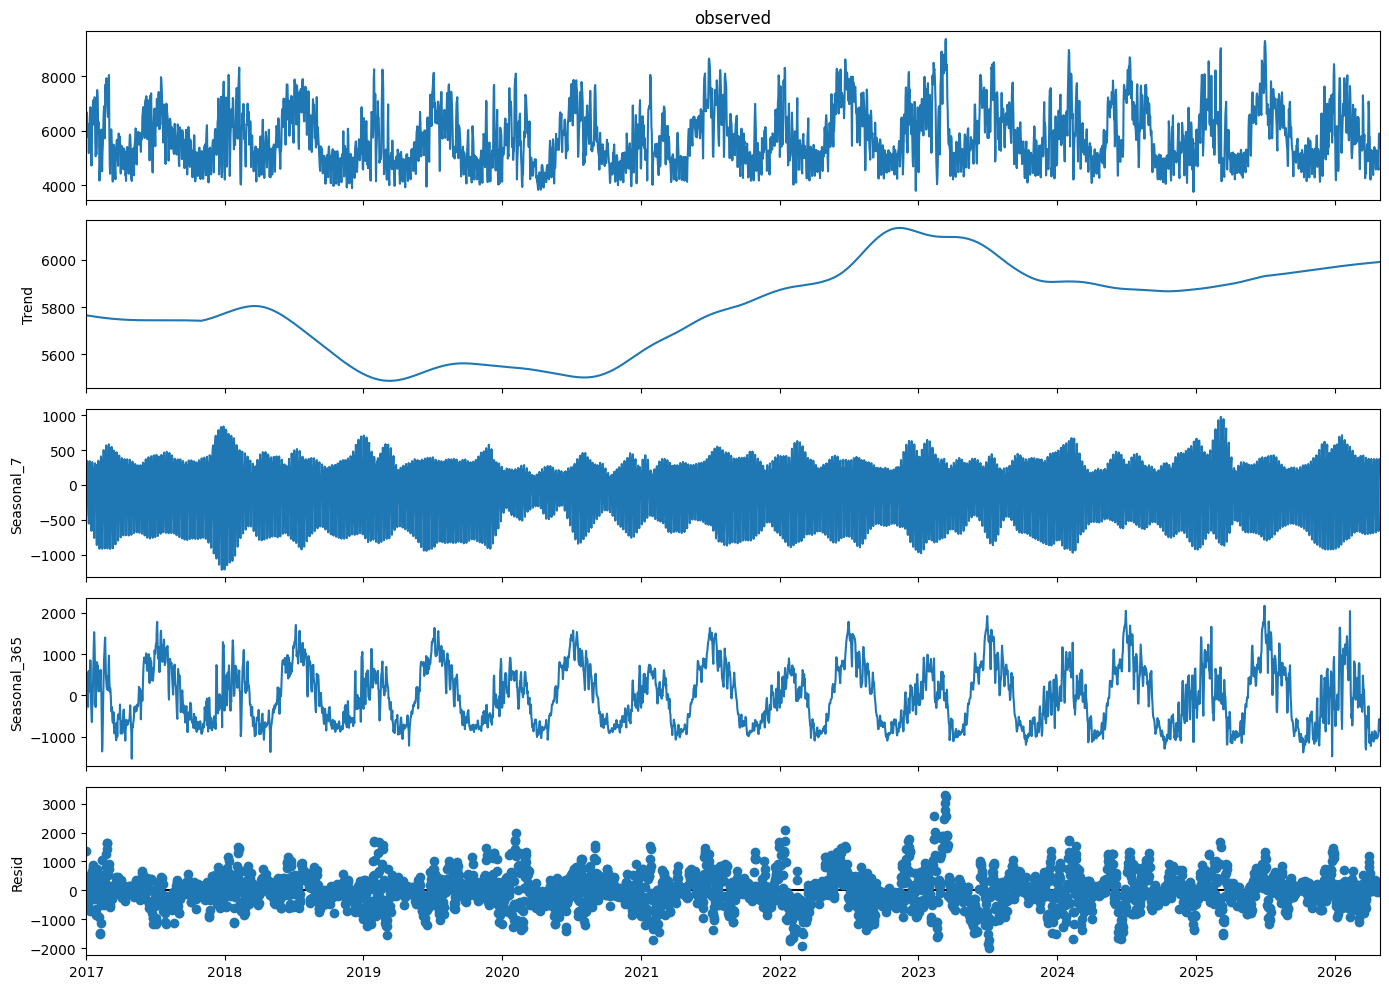

In [8]:
from statsmodels.tsa.seasonal import MSTL

# Se arma una serie diaria regular para la descomposición.
serie_mstl_demanda = (
    demanda_gbsas[["fecha", "demanda"]]
    .dropna(subset=["fecha", "demanda"])
    .drop_duplicates(subset="fecha")
    .sort_values("fecha")
    .set_index("fecha")["demanda"]
    .asfreq("D")
)

# Se completan faltantes temporales para sostener la frecuencia diaria.
serie_mstl_demanda = serie_mstl_demanda.interpolate(method="time").ffill().bfill()

mstl_demanda = MSTL(serie_mstl_demanda, periods=(7, 365))
resultado_mstl_demanda = mstl_demanda.fit()

fig = resultado_mstl_demanda.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()


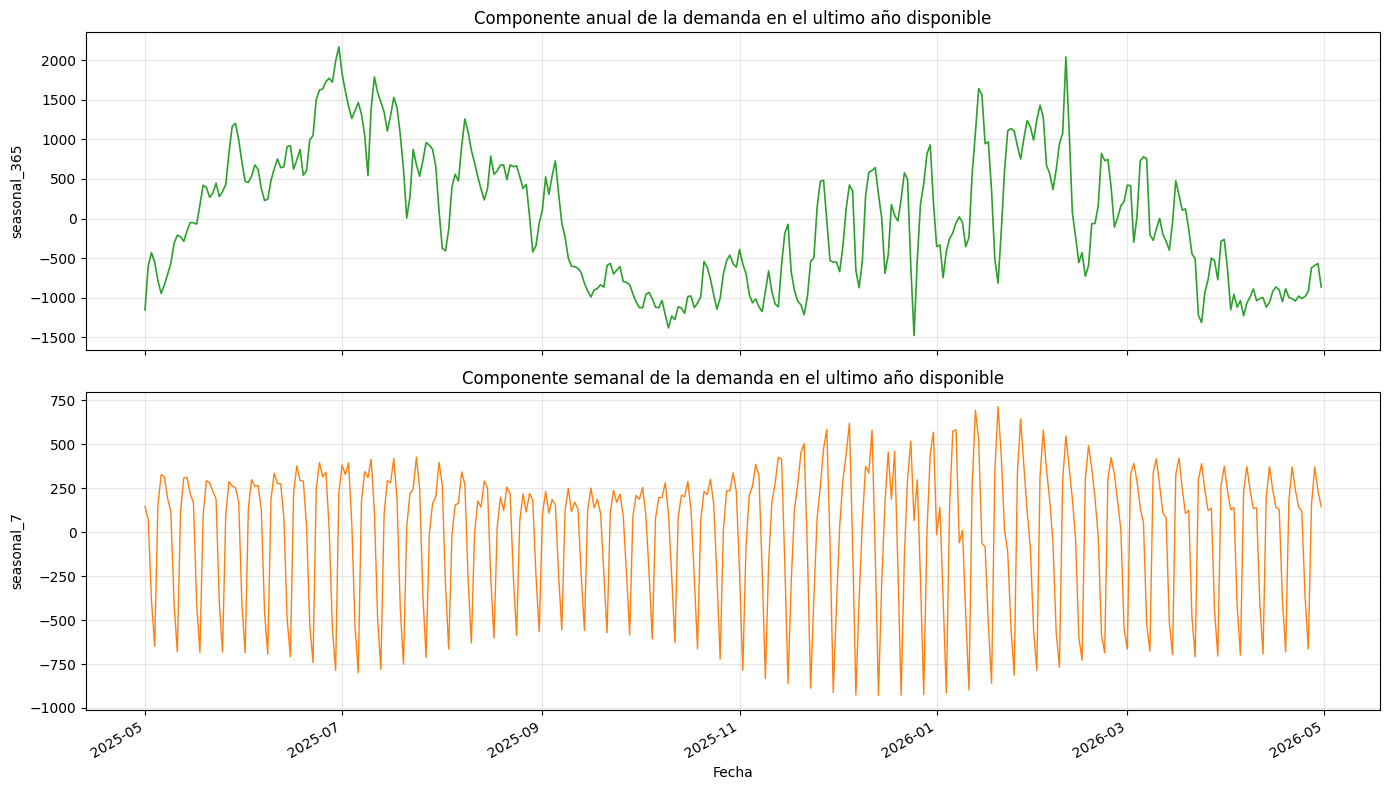

In [9]:
seasonal_mstl_demanda = resultado_mstl_demanda.seasonal.copy()
inicio_ultimo_anio = seasonal_mstl_demanda.index.max() - pd.Timedelta(days=364)
seasonal_mstl_ultimo_anio = seasonal_mstl_demanda.loc[inicio_ultimo_anio:]

# Se grafica un año para observar con mayor detalle las estacionalidades.
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(
    seasonal_mstl_ultimo_anio.index,
    seasonal_mstl_ultimo_anio["seasonal_365"],
    color="tab:green",
    linewidth=1.2,
)
axes[0].set_ylabel("seasonal_365")
axes[0].set_title("Componente anual de la demanda en el ultimo año disponible")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    seasonal_mstl_ultimo_anio.index,
    seasonal_mstl_ultimo_anio["seasonal_7"],
    color="tab:orange",
    linewidth=1.0,
)
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("seasonal_7")
axes[1].set_title("Componente semanal de la demanda en el ultimo año disponible")
axes[1].grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### Análisis de la descomposición MSTL
La descomposición muestra dos patrones relevantes en la demanda. La componente anual presenta variaciones de gran amplitud, con valores positivos en torno a los meses de mayor demanda y valores negativos en períodos de menor contribución estacional. En este último año disponible, la señal anual no es perfectamente suave: aparecen oscilaciones y picos marcados, lo que insinúa que la estacionalidad anual está influida por eventos de corto plazo o por variabilidad no completamente separada por la descomposición.

La componente semanal es más clara y regular. Se observa un patrón repetitivo de período aproximado de 7 días, con caídas pronunciadas y recuperaciones sistemáticas dentro de cada semana. Esto evidencia que la demanda diaria tiene una estructura semanal fuerte, probablemente asociada a diferencias entre días hábiles y fines de semana.

En la tendencia, se observa una caída desde 2017 hasta aproximadamente 2019-2020, luego una recuperación marcada desde 2021, con un máximo alrededor de 2022-2023. Después parece bajar algo durante 2024 y volver a crecer suavemente hacia 2025-2026.

###  Prueba de estacionaridad ADF

In [10]:
from statsmodels.tsa.stattools import adfuller

# Se aplica la prueba ADF sobre la serie de demanda diaria regularizada.
resultado_adf = adfuller(serie_mstl_demanda.dropna(), autolag="AIC")

resumen_adf = pd.Series(
    {
        "estadistico_adf": resultado_adf[0],
        "p_value": resultado_adf[1],
        "lags_usados": resultado_adf[2],
        "n_observaciones": resultado_adf[3],
    }
)
valores_criticos_adf = pd.Series(resultado_adf[4], name="valor_critico")

display(resumen_adf.to_frame(name="valor"))
display(valores_criticos_adf.to_frame())

if resumen_adf["p_value"] < 0.05:
    print("Se rechaza la hipótesis nula de raíz unitaria al 5%.")
    print("La serie puede considerarse estacionaria bajo este contraste.")
else:
    print("No se rechaza la hipótesis nula de raíz unitaria al 5%.")
    print("La serie no puede considerarse estacionaria bajo este contraste.")


,valor
estadistico_adf,-6.153047e+00
p_value,7.481779e-08
lags_usados,2.900000e+01
n_observaciones,3.377000e+03


,valor_critico
1%,-3.432288
5%,-2.862396
10%,-2.567226


Se rechaza la hipótesis nula de raíz unitaria al 5%.
La serie puede considerarse estacionaria bajo este contraste.


### Análisis de la prueba de estacionaridad.
La prueba ADF aplicada a la serie de demanda diaria arrojó un estadístico de $−6.153$ y un p-value de $7.48×10^{−8}$. Dado que el p-value es menor que $0.05$, se rechaza la hipótesis nula. Por lo tanto, se cuenta con evidencia a favor de estacionariedad en nivel, por lo que inicialmente se considerará d=0 en la especificación SARIMA. No obstante, se realiza el análisis de autocorrelación para evaluar la presencia de estructura estacional semanal.

### Autocorrelación (ACF) y autocorrelación parcial (PACF)

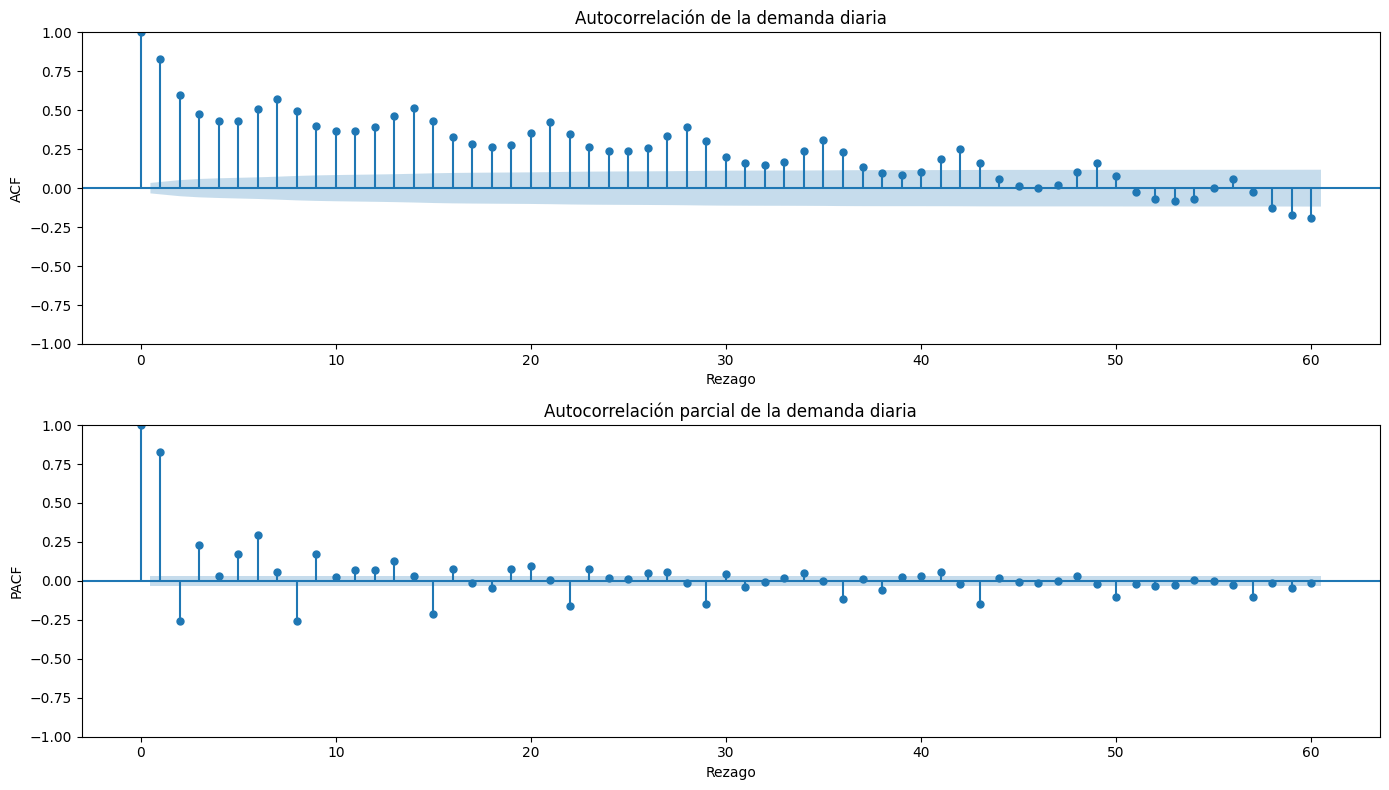

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Se calculan ACF y PACF sobre la serie diaria regularizada.
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(serie_mstl_demanda.dropna(), lags=60, ax=axes[0])
axes[0].set_title("Autocorrelación de la demanda diaria")
axes[0].set_xlabel("Rezago")
axes[0].set_ylabel("ACF")

plot_pacf(serie_mstl_demanda.dropna(), lags=60, ax=axes[1], method="ywm")
axes[1].set_title("Autocorrelación parcial de la demanda diaria")
axes[1].set_xlabel("Rezago")
axes[1].set_ylabel("PACF")

plt.tight_layout()
plt.show()


### Análisis de la autocorrelación (ACF) y autocorrelación parcial (PACF)

Los gráficos ACF y PACF muestran dependencia temporal en la demanda diaria. La ACF mantiene valores significativos durante varios rezagos. La PACF presenta un pico dominante en el rezago 1, lo que indica una componente autorregresiva de corto plazo.

Como la prueba ADF indicó estacionalidad en nivel, se considera inicialmente d=0. Por eso se comenzará con modelos ARIMA(p,0,q) de bajo orden. Este modelo se tomará como referencia inicial; luego, si los residuos muestran autocorrelación semanal, se justificará avanzar hacia SARIMA con s=7.

### Separación de los datos para entrenamiento y testeo 

In [12]:
demanda_gbsas = demanda_gbsas.sort_values("fecha").reset_index(drop=True)

# Se divide la muestra en entrenamiento 2017-2024 y prueba 2025-2026.
train_gbsas = demanda_gbsas.loc[
    demanda_gbsas["fecha"] < pd.Timestamp("2025-01-01")
].copy()
test_gbsas = demanda_gbsas.loc[
    demanda_gbsas["fecha"] >= pd.Timestamp("2025-01-01")
].copy()

# Se fija frecuencia diaria explicita para evitar inferencias automáticas.
train_gbsas = train_gbsas.set_index("fecha").asfreq("D")
test_gbsas = test_gbsas.set_index("fecha").asfreq("D")

# Se separan la serie objetivo y la variable exógena potencial.
demanda_train = train_gbsas["demanda"]
demanda_test = test_gbsas["demanda"]
temp_train = train_gbsas["temp_media"]
temp_test = test_gbsas["temp_media"]

display(train_gbsas[["demanda", "temp_media"]].head())
display(test_gbsas[["demanda", "temp_media"]].head())

,demanda,temp_media
fecha,,
2017-01-01,6352.695208,31.30
2017-01-02,6617.863750,25.35
2017-01-03,6677.996167,25.45
2017-01-04,6426.997625,27.00
2017-01-05,5873.950750,21.90


,demanda,temp_media
fecha,,
2025-01-01,5479.494333,27.75
2025-01-02,6047.826292,26.70
2025-01-03,5501.353375,22.95
2025-01-04,4940.960708,20.60
2025-01-05,4702.411500,22.05


## ARIMA

In [13]:
from statsmodels.tsa.arima.model import ARIMA

ordenes_arima = [(1, 0, 1), (2, 0, 1), (1, 0, 2), (2, 0, 2)]
modelos_arima = {}
resumen_modelos_arima = []

# Se ajustan los modelos candidatos sobre la serie de entrenamiento.
for orden in ordenes_arima:
    modelo = ARIMA(demanda_train, order=orden)
    resultado = modelo.fit()
    modelos_arima[orden] = resultado

    resumen_modelos_arima.append(
        {
            "modelo": f"ARIMA{orden}",
            "aic": resultado.aic,
            "bic": resultado.bic,
            "hqic": resultado.hqic,
            "loglik": resultado.llf,
            "convergencia": resultado.mle_retvals.get("converged", False),
        }
    )

comparacion_arima = (
    pd.DataFrame(resumen_modelos_arima)
    .sort_values("aic")
    .reset_index(drop=True)
)
mejor_modelo_arima = comparacion_arima.loc[0, "modelo"]

# Se muestra el informe completo y el estado de convergencia de cada modelo.
for orden in ordenes_arima:
    convergio = modelos_arima[orden].mle_retvals.get("converged", False)
    print("=" * 80)
    print(f"ARIMA{orden}")
    print(f"Convergencia: {convergio}")
    print("=" * 80)
    display(modelos_arima[orden].summary())


C:\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(1, 0, 1)
Convergencia: True


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                demanda   No. Observations:                 2922
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -22509.956
Date:                Thu, 18 Jun 2026   AIC                          45027.912
Time:                        12:08:41   BIC                          45051.832
Sample:                    01-01-2017   HQIC                         45036.528
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5765.4967     49.448    116.596      0.000    5668.580    5862.414
ar.L1          0.7053      0.015     46.123      0.000       0.675       0.735
ma.L1          0.4303      0.019     23.220      0.000       0.394       0.467
sigma2      2.886e+05   6823.947     42.286      0.000    2.75e+05    3.02e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.78   Jarque-Bera (JB):               106.98
Prob(Q):                              0.38   Prob(JB):                         0.00
Heteroskedasticity (H):               0.98   Skew:                             0.30
Prob(H) (two-sided):                  0.73   Kurtosis:                         3.72
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

ARIMA(2, 0, 1)
Convergencia: True


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                demanda   No. Observations:                 2922
Model:                 ARIMA(2, 0, 1)   Log Likelihood              -22506.279
Date:                Thu, 18 Jun 2026   AIC                          45022.558
Time:                        12:08:41   BIC                          45052.459
Sample:                    01-01-2017   HQIC                         45033.328
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5765.4967     52.441    109.943      0.000    5662.714    5868.279
ar.L1          0.5828      0.045     12.952      0.000       0.495       0.671
ar.L2          0.1158      0.041      2.849      0.004       0.036       0.195
ma.L1          0.5364      0.039     13.755      0.000       0.460       0.613
sigma2      2.826e+05   6537.397     43.230      0.000     2.7e+05    2.95e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                96.28
Prob(Q):                              0.80   Prob(JB):                         0.00
Heteroskedasticity (H):               0.97   Skew:                             0.26
Prob(H) (two-sided):                  0.67   Kurtosis:                         3.72
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

ARIMA(1, 0, 2)
Convergencia: True


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                demanda   No. Observations:                 2922
Model:                 ARIMA(1, 0, 2)   Log Likelihood              -22500.765
Date:                Thu, 18 Jun 2026   AIC                          45011.530
Time:                        12:08:41   BIC                          45041.430
Sample:                    01-01-2017   HQIC                         45022.300
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5765.4967     59.943     96.183      0.000    5648.011    5882.982
ar.L1          0.8116      0.017     48.415      0.000       0.779       0.844
ma.L1          0.2702      0.025     10.940      0.000       0.222       0.319
ma.L2         -0.1848      0.023     -8.045      0.000      -0.230      -0.140
sigma2      2.843e+05   6630.149     42.886      0.000    2.71e+05    2.97e+05
===================================================================================
Ljung-Box (L1) (Q):                   1.35   Jarque-Bera (JB):                73.25
Prob(Q):                              0.25   Prob(JB):                         0.00
Heteroskedasticity (H):               0.97   Skew:                             0.18
Prob(H) (two-sided):                  0.60   Kurtosis:                         3.68
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

ARIMA(2, 0, 2)
Convergencia: True


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                demanda   No. Observations:                 2922
Model:                 ARIMA(2, 0, 2)   Log Likelihood              -22420.184
Date:                Thu, 18 Jun 2026   AIC                          44852.369
Time:                        12:08:41   BIC                          44888.249
Sample:                    01-01-2017   HQIC                         44865.292
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5765.4968    134.337     42.918      0.000    5502.201    6028.793
ar.L1          1.4121      0.032     44.539      0.000       1.350       1.474
ar.L2         -0.4247      0.029    -14.519      0.000      -0.482      -0.367
ma.L1         -0.3739      0.030    -12.333      0.000      -0.433      -0.315
ma.L2         -0.4589      0.017    -26.750      0.000      -0.493      -0.425
sigma2      2.714e+05   6414.298     42.307      0.000    2.59e+05    2.84e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.93   Jarque-Bera (JB):                51.08
Prob(Q):                              0.34   Prob(JB):                         0.00
Heteroskedasticity (H):               0.99   Skew:                             0.12
Prob(H) (two-sided):                  0.89   Kurtosis:                         3.60
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Análisis modelos ARIMA 
Comparando los modelos ARIMA estimados, el ARIMA(2,0,2) muestra mejor ajuste que el ARIMA(1,0,1), con menores valores de AIC y BIC, mayor log-verosimilitud y menor varianza residual estimada. Dado que la serie presenta señales de estacionalidad semanal, este modelo se toma como referencia no estacional y se complementará con el análisis de residuos antes de avanzar hacia modelos SARIMA.

### Pronóstico con ARIMA

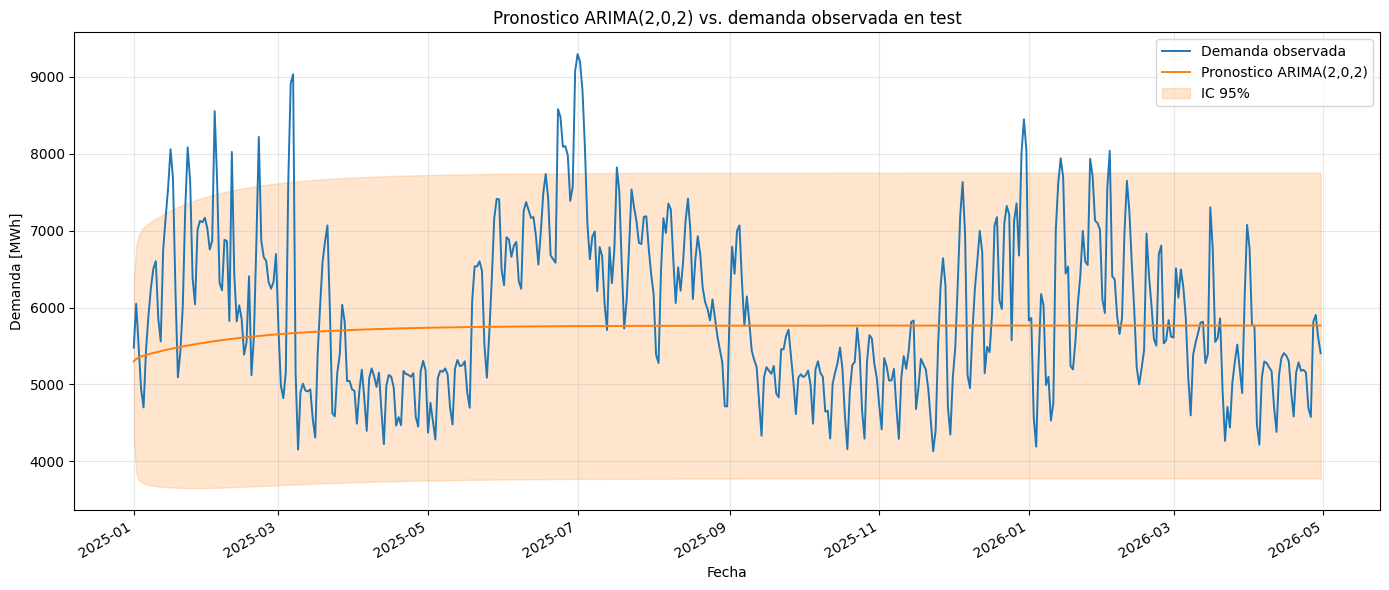

In [14]:
resultado_arima_202 = modelos_arima[(2, 0, 2)]
pronostico_arima_202 = resultado_arima_202.get_forecast(steps=len(demanda_test))
media_pronosticada_arima_202 = pronostico_arima_202.predicted_mean
intervalos_pronostico_arima_202 = pronostico_arima_202.conf_int()

# Se compara el pronóstico fuera de muestra con la serie observada en test.
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(demanda_test.index, demanda_test, label="Demanda observada", color="tab:blue", linewidth=1.4)
ax.plot(
    media_pronosticada_arima_202.index,
    media_pronosticada_arima_202,
    label="Pronostico ARIMA(2,0,2)",
    color="tab:orange",
    linewidth=1.4,
)
ax.fill_between(
    intervalos_pronostico_arima_202.index,
    intervalos_pronostico_arima_202.iloc[:, 0],
    intervalos_pronostico_arima_202.iloc[:, 1],
    color="tab:orange",
    alpha=0.2,
    label="IC 95%",
)

ax.set_title("Pronostico ARIMA(2,0,2) vs. demanda observada en test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Demanda [MWh]")
ax.grid(True, alpha=0.3)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [15]:
# Se calculan métricas de error sobre el periodo de test para ARIMA.
errores_arima_202 = demanda_test - media_pronosticada_arima_202
metricas_arima_202 = pd.Series(
    {
        "MAE": errores_arima_202.abs().mean(),
        "RMSE": (errores_arima_202.pow(2).mean()) ** 0.5,
        "MAPE": (errores_arima_202.abs().div(demanda_test).mean()) * 100,
    },
    name="ARIMA(2,0,2)",
)

metricas_arima_202.to_frame(name="valor")


,valor
MAE,881.686303
RMSE,1082.037241
MAPE,14.533023


**El ARIMA(2,0,2) funciona como modelo base no estacional, pero es insuficiente para captar la estructura de la demanda diaria, por lo que es necesario avanzar a modelos con componente estacional, como SARIMA con s=7, y luego SARIMAX incorporando temperatura**

## SARIMA con estacionalidad 7

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Se parte del mejor ARIMA no estacional y se agrega estacionalidad semanal.
modelo_sarima_202_1017 = SARIMAX(
    demanda_train,
    order=(2, 0, 2),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
resultado_sarima_202_1017 = modelo_sarima_202_1017.fit(disp=False, maxiter=1000)

comparacion_base_sarima = pd.DataFrame(
    [
        {
            "modelo": "ARIMA(2,0,2)",
            "aic": modelos_arima[(2, 0, 2)].aic,
            "bic": modelos_arima[(2, 0, 2)].bic,
            "hqic": modelos_arima[(2, 0, 2)].hqic,
            "loglik": modelos_arima[(2, 0, 2)].llf,
        },
        {
            "modelo": "SARIMA(2,0,2)x(1,0,1,7)",
            "aic": resultado_sarima_202_1017.aic,
            "bic": resultado_sarima_202_1017.bic,
            "hqic": resultado_sarima_202_1017.hqic,
            "loglik": resultado_sarima_202_1017.llf,
        },
    ]
)

print(
    f"Convergencia SARIMA: {resultado_sarima_202_1017.mle_retvals.get('converged', False)}"
)
display(comparacion_base_sarima)
display(resultado_sarima_202_1017.summary())


Convergencia SARIMA: True


,modelo,aic,bic,hqic,loglik
0,"ARIMA(2,0,2)",44852.368943,44888.249085,44865.292239,-22420.184471
1,"SARIMA(2,0,2)x(1,0,1,7)",43670.341948,43712.178116,43685.413112,-21828.170974


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                             demanda   No. Observations:                 2922
Model:             SARIMAX(2, 0, 2)x(1, 0, [1], 7)   Log Likelihood              -21828.171
Date:                             Thu, 18 Jun 2026   AIC                          43670.342
Time:                                     12:08:46   BIC                          43712.178
Sample:                                 01-01-2017   HQIC                         43685.413
                                      - 12-31-2024                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5626      0.052     29.777      0.000       1.460       1.665
ar.L2         -0.5729      0.049    -11.798      0.000      -0.668      -0.478
ma.L1         -0.4569      0.052     -8.704      0.000      -0.560      -0.354
ma.L2         -0.3756      0.024    -15.417      0.000      -0.423      -0.328
ar.S.L7        0.9998      0.000   3186.058      0.000       0.999       1.000
ma.S.L7       -0.9918      0.007   -142.493      0.000      -1.005      -0.978
sigma2      2.774e+05   8805.499     31.502      0.000     2.6e+05    2.95e+05
===================================================================================
Ljung-Box (L1) (Q):                   1.65   Jarque-Bera (JB):               362.69
Prob(Q):                              0.20   Prob(JB):                         0.00
Heteroskedasticity (H):               1.08   Skew:                            -0.15
Prob(H) (two-sided):                  0.24   Kurtosis:                         4.70
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 9.34e+14. Standard errors may be unstable.
"""

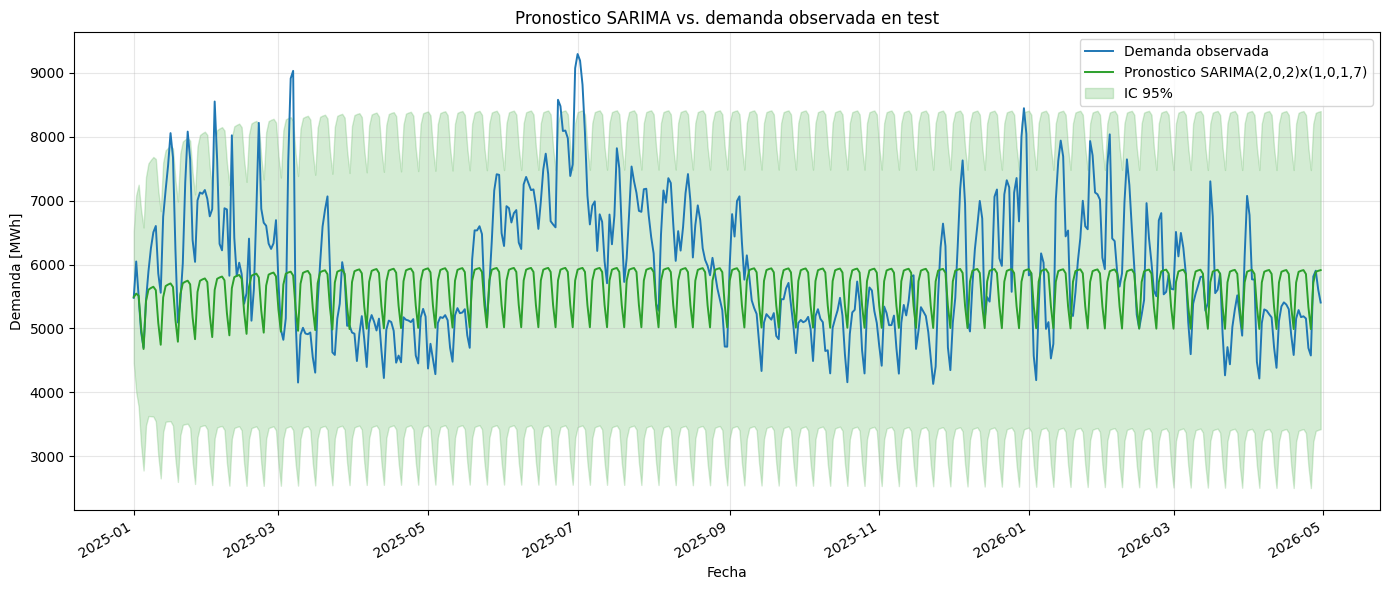

In [17]:
pronostico_sarima_202_1017 = resultado_sarima_202_1017.get_forecast(steps=len(demanda_test))
media_pronosticada_sarima_202_1017 = pronostico_sarima_202_1017.predicted_mean
intervalos_pronostico_sarima_202_1017 = pronostico_sarima_202_1017.conf_int()

# Se compara el pronóstico SARIMA fuera de muestra con la serie observada en test.
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(demanda_test.index, demanda_test, label="Demanda observada", color="tab:blue", linewidth=1.4)
ax.plot(
    media_pronosticada_sarima_202_1017.index,
    media_pronosticada_sarima_202_1017,
    label="Pronostico SARIMA(2,0,2)x(1,0,1,7)",
    color="tab:green",
    linewidth=1.4,
)
ax.fill_between(
    intervalos_pronostico_sarima_202_1017.index,
    intervalos_pronostico_sarima_202_1017.iloc[:, 0],
    intervalos_pronostico_sarima_202_1017.iloc[:, 1],
    color="tab:green",
    alpha=0.2,
    label="IC 95%",
)

ax.set_title("Pronostico SARIMA vs. demanda observada en test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Demanda [MWh]")
ax.grid(True, alpha=0.3)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


El modelo captura una estacionalidad semanal regular, pero no los cambios anuales ni los picos asociados a condiciones externas.

In [18]:
# Se calculan métricas de error sobre el periodo de test para SARIMA.
errores_sarima_202_1017 = demanda_test - media_pronosticada_sarima_202_1017
metricas_sarima_202_1017 = pd.Series(
    {
        "MAE": errores_sarima_202_1017.abs().mean(),
        "RMSE": (errores_sarima_202_1017.pow(2).mean()) ** 0.5,
        "MAPE": (errores_sarima_202_1017.abs().div(demanda_test).mean()) * 100,
    },
    name="SARIMA(2,0,2)x(1,0,1,7)",
)

metricas_sarima_202_1017.to_frame(name="valor")


,valor
MAE,839.677922
RMSE,1031.846332
MAPE,13.541599


## SARIMAX con temperatura
Se plantea incorporar al modelo la variable exógena: temperatura media diaria.

Se realiza al igual que el caso anterior una exploración acotada de los grados de AR y MA. Y se congelan los grados estacionales en (1,1,1,7)
 

In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Se entrena una familia de modelos SARIMAX con temperatura exógena y orden hasta 2.
ordenes_sarimax = [(1, 0, 1), (2, 0, 1), (1, 0, 2), (2, 0, 2)]
modelos_sarimax = {}
filas_sarimax = []

for orden in ordenes_sarimax:
    modelo_sarimax = SARIMAX(
        demanda_train,
        exog=temp_train.to_frame(name="temp_media"),
        order=orden,
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    resultado_sarimax = modelo_sarimax.fit(maxiter=1000,disp=False)
    modelos_sarimax[orden] = resultado_sarimax
    filas_sarimax.append(
        {
            "modelo": f"SARIMAX{orden}x(1,1,1,7)",
            "orden": orden,
            "aic": resultado_sarimax.aic,
            "bic": resultado_sarimax.bic,
            "hqic": resultado_sarimax.hqic,
            "loglik": resultado_sarimax.llf,
            "converged": resultado_sarimax.mle_retvals.get("converged", False),
        }
    )

comparacion_sarimax = pd.DataFrame(filas_sarimax).sort_values("aic").reset_index(drop=True)
mejor_orden_sarimax = comparacion_sarimax.loc[0, "orden"]
mejor_resultado_sarimax = modelos_sarimax[mejor_orden_sarimax]

display(comparacion_sarimax)

for orden in ordenes_sarimax:
    print("=" * 80)
    print(f"SARIMAX{orden}x(1,1,1,7) con temperatura")
    print("=" * 80)
    display(modelos_sarimax[orden].summary())


,modelo,orden,aic,bic,hqic,loglik,converged
0,"SARIMAX(2, 0, 2)x(1,1,1,7)","(2, 0, 2)",43202.370297,43250.163806,43219.589655,-21593.185148,True
1,"SARIMAX(1, 0, 2)x(1,1,1,7)","(1, 0, 2)",43308.473968,43350.293289,43323.540907,-21647.236984,True
2,"SARIMAX(1, 0, 1)x(1,1,1,7)","(1, 0, 1)",43331.640671,43367.487868,43344.555708,-21659.820335,True
3,"SARIMAX(2, 0, 1)x(1,1,1,7)","(2, 0, 1)",43332.234018,43374.055747,43347.301561,-21659.117009,True


SARIMAX(1, 0, 1)x(1,1,1,7) con temperatura


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                           demanda   No. Observations:                 2922
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 7)   Log Likelihood              -21659.820
Date:                           Thu, 18 Jun 2026   AIC                          43331.641
Time:                                   12:10:29   BIC                          43367.488
Sample:                               01-01-2017   HQIC                         43344.556
                                    - 12-31-2024                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp_media    16.3948      2.097      7.819      0.000      12.285      20.504
ar.L1          0.8203      0.012     68.215      0.000       0.797       0.844
ma.L1          0.3613      0.016     22.919      0.000       0.330       0.392
ar.S.L7        0.0379      0.017      2.250      0.024       0.005       0.071
ma.S.L7       -0.9954      0.004   -234.734      0.000      -1.004      -0.987
sigma2      1.727e+05   3523.925     49.014      0.000    1.66e+05     1.8e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.22   Jarque-Bera (JB):               361.39
Prob(Q):                              0.64   Prob(JB):                         0.00
Heteroskedasticity (H):               1.09   Skew:                             0.01
Prob(H) (two-sided):                  0.16   Kurtosis:                         4.73
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

SARIMAX(2, 0, 1)x(1,1,1,7) con temperatura


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                           demanda   No. Observations:                 2922
Model:             SARIMAX(2, 0, 1)x(1, 1, 1, 7)   Log Likelihood              -21659.117
Date:                           Thu, 18 Jun 2026   AIC                          43332.234
Time:                                   12:10:29   BIC                          43374.056
Sample:                               01-01-2017   HQIC                         43347.302
                                    - 12-31-2024                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp_media    16.5093      2.099      7.866      0.000      12.395      20.623
ar.L1          0.7685      0.047     16.197      0.000       0.676       0.862
ar.L2          0.0503      0.045      1.129      0.259      -0.037       0.138
ma.L1          0.4058      0.044      9.276      0.000       0.320       0.492
ar.S.L7        0.0346      0.017      2.032      0.042       0.001       0.068
ma.S.L7       -1.0046      0.004   -231.574      0.000      -1.013      -0.996
sigma2       1.71e+05   3694.328     46.292      0.000    1.64e+05    1.78e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):               360.57
Prob(Q):                              0.87   Prob(JB):                         0.00
Heteroskedasticity (H):               1.09   Skew:                             0.01
Prob(H) (two-sided):                  0.16   Kurtosis:                         4.73
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

SARIMAX(1, 0, 2)x(1,1,1,7) con temperatura


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                             demanda   No. Observations:                 2922
Model:             SARIMAX(1, 0, 2)x(1, 1, [1], 7)   Log Likelihood              -21647.237
Date:                             Thu, 18 Jun 2026   AIC                          43308.474
Time:                                     12:10:29   BIC                          43350.293
Sample:                                 01-01-2017   HQIC                         43323.541
                                      - 12-31-2024                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp_media    16.3660      2.103      7.783      0.000      12.245      20.487
ar.L1          0.8459      0.014     62.355      0.000       0.819       0.872
ma.L1          0.3157      0.020     15.935      0.000       0.277       0.354
ma.L2         -0.0611      0.020     -3.042      0.002      -0.100      -0.022
ar.S.L7        0.0279      0.017      1.629      0.103      -0.006       0.062
ma.S.L7       -0.9955      0.004   -228.586      0.000      -1.004      -0.987
sigma2      1.722e+05   3516.453     48.967      0.000    1.65e+05    1.79e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.15   Jarque-Bera (JB):               356.51
Prob(Q):                              0.70   Prob(JB):                         0.00
Heteroskedasticity (H):               1.10   Skew:                            -0.00
Prob(H) (two-sided):                  0.13   Kurtosis:                         4.72
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

SARIMAX(2, 0, 2)x(1,1,1,7) con temperatura


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                             demanda   No. Observations:                 2922
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 7)   Log Likelihood              -21593.185
Date:                             Thu, 18 Jun 2026   AIC                          43202.370
Time:                                     12:10:29   BIC                          43250.164
Sample:                                 01-01-2017   HQIC                         43219.590
                                      - 12-31-2024                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp_media    18.3717      2.141      8.582      0.000      14.176      22.567
ar.L1          1.5749      0.034     46.700      0.000       1.509       1.641
ar.L2         -0.5837      0.032    -18.479      0.000      -0.646      -0.522
ma.L1         -0.4580      0.034    -13.593      0.000      -0.524      -0.392
ma.L2         -0.3814      0.015    -24.882      0.000      -0.411      -0.351
ar.S.L7       -0.0034      0.018     -0.188      0.851      -0.038       0.032
ma.S.L7       -0.9999      0.144     -6.943      0.000      -1.282      -0.718
sigma2      1.654e+05   2.38e+04      6.942      0.000    1.19e+05    2.12e+05
===================================================================================
Ljung-Box (L1) (Q):                   1.12   Jarque-Bera (JB):               284.67
Prob(Q):                              0.29   Prob(JB):                         0.00
Heteroskedasticity (H):               1.13   Skew:                            -0.07
Prob(H) (two-sided):                  0.06   Kurtosis:                         4.53
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

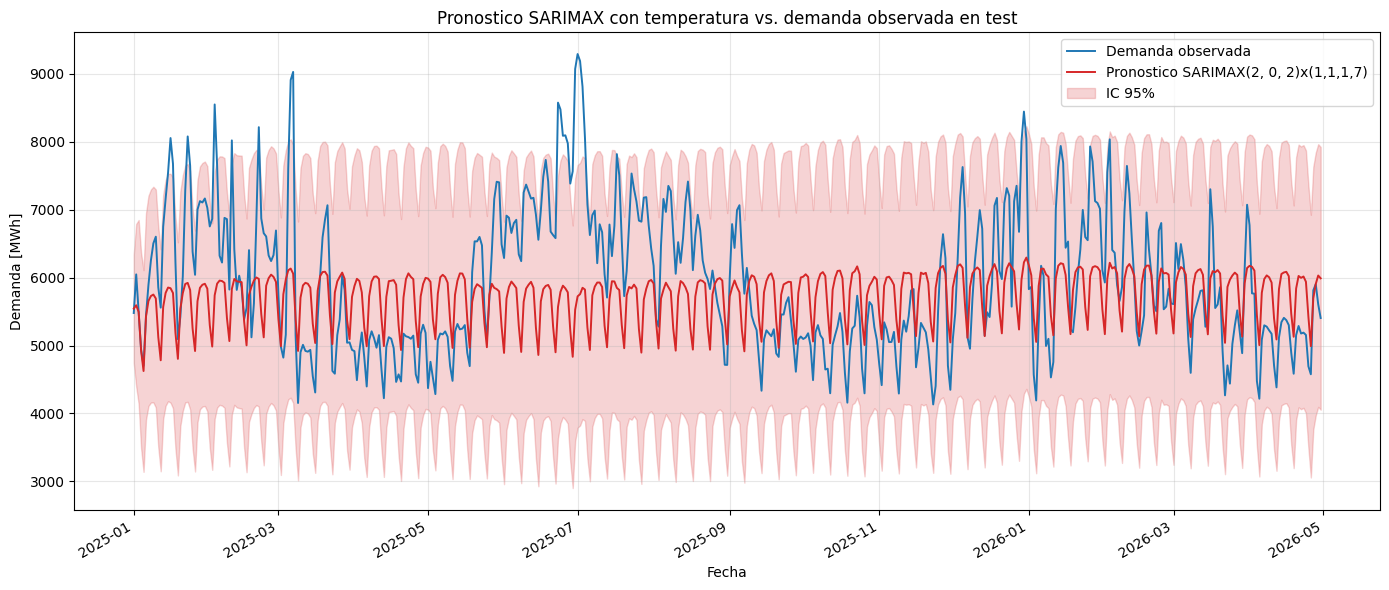

In [20]:
# Se genera el pronostico fuera de muestra con el mejor SARIMAX segun AIC.
pronostico_sarimax = mejor_resultado_sarimax.get_forecast(
    steps=len(demanda_test),
    exog=temp_test.to_frame(name="temp_media"),
)
media_pronosticada_sarimax = pronostico_sarimax.predicted_mean
intervalos_pronostico_sarimax = pronostico_sarimax.conf_int()

# Se compara el pronostico SARIMAX con la serie observada en test.
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(demanda_test.index, demanda_test, label="Demanda observada", color="tab:blue", linewidth=1.4)
ax.plot(
    media_pronosticada_sarimax.index,
    media_pronosticada_sarimax,
    label=f"Pronostico SARIMAX{mejor_orden_sarimax}x(1,1,1,7)",
    color="tab:red",
    linewidth=1.4,
)
ax.fill_between(
    intervalos_pronostico_sarimax.index,
    intervalos_pronostico_sarimax.iloc[:, 0],
    intervalos_pronostico_sarimax.iloc[:, 1],
    color="tab:red",
    alpha=0.2,
    label="IC 95%",
)

ax.set_title("Pronostico SARIMAX con temperatura vs. demanda observada en test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Demanda [MWh]")
ax.grid(True, alpha=0.3)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


El modelo muestras mejoras en las métricas comparado con ARIMA, captura bien una estacionalidad semanal regular, levemente toma registro de los cambios anuales pero sigue sin registrar los picos asociados a condiciones externas.

In [21]:
# Se calculan metricas de error sobre el periodo de test para SARIMAX.
errores_sarimax = demanda_test - media_pronosticada_sarimax
metricas_sarimax = pd.Series(
    {
        "MAE": errores_sarimax.abs().mean(),
        "RMSE": (errores_sarimax.pow(2).mean()) ** 0.5,
        "MAPE": (errores_sarimax.abs().div(demanda_test).mean()) * 100,
    },
    name=f"SARIMAX{mejor_orden_sarimax}x(1,1,1,7)",
)

metricas_sarimax.to_frame(name="valor")


,valor
MAE,842.152362
RMSE,1023.075451
MAPE,13.741523


## SARIMAX con temperatura centrada y termino cuadratico

Para este caso se usarán dos variables exógenas la temperatura media diaria centrada y si potencia cuadrada:

$
T_c = T_t - \bar T_{\text{train}}
$

$
T_c^2 = (T_t - \bar T_{\text{train}})^2
$

De esta manera se pretende que término cuadrático sea más estable numéricamente.

Se realiza, al igual que el caso anterior, una exploración acotada de los grados de AR y MA. Y se congelan los grados estacionales en (1,1,1,7)

In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Se calcula la media de temperatura solo con train y se construyen las exogenas transformadas.
temp_media_train = temp_train.mean()
temp_train_centrada = temp_train - temp_media_train
temp_test_centrada = temp_test - temp_media_train

exog_train_centrada = pd.DataFrame(
    {
        "temp_centrada": temp_train_centrada,
        "temp_centrada_cuadrado": temp_train_centrada.pow(2),
    },
    index=demanda_train.index,
)
exog_test_centrada = pd.DataFrame(
    {
        "temp_centrada": temp_test_centrada,
        "temp_centrada_cuadrado": temp_test_centrada.pow(2),
    },
    index=demanda_test.index,
)

# Se entrena una familia de SARIMAX con las dos variables exogenas y orden hasta 2.
ordenes_sarimax_centrado = [(1, 0, 1), (2, 0, 1), (1, 0, 2), (2, 0, 2)]
modelos_sarimax_centrado = {}
filas_sarimax_centrado = []

for orden in ordenes_sarimax_centrado:
    modelo_sarimax_centrado = SARIMAX(
        demanda_train,
        exog=exog_train_centrada,
        order=orden,
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    resultado_sarimax_centrado = modelo_sarimax_centrado.fit(maxiter=1000,disp=False)
    modelos_sarimax_centrado[orden] = resultado_sarimax_centrado
    filas_sarimax_centrado.append(
        {
            "modelo": f"SARIMAX{orden}x(1,1,1,7)",
            "orden": orden,
            "aic": resultado_sarimax_centrado.aic,
            "bic": resultado_sarimax_centrado.bic,
            "hqic": resultado_sarimax_centrado.hqic,
            "loglik": resultado_sarimax_centrado.llf,
            "converged": resultado_sarimax_centrado.mle_retvals.get("converged", False),
        }
    )

comparacion_sarimax_centrado = (
    pd.DataFrame(filas_sarimax_centrado).sort_values("aic").reset_index(drop=True)
)
mejor_orden_sarimax_centrado = comparacion_sarimax_centrado.loc[0, "orden"]
mejor_resultado_sarimax_centrado = modelos_sarimax_centrado[mejor_orden_sarimax_centrado]

display(comparacion_sarimax_centrado)

for orden in ordenes_sarimax_centrado:
    print("=" * 80)
    print(f"SARIMAX{orden}x(1,1,1,7) con temperatura centrada")
    print("=" * 80)
    display(modelos_sarimax_centrado[orden].summary())


,modelo,orden,aic,bic,hqic,loglik,converged
0,"SARIMAX(2, 0, 2)x(1,1,1,7)","(2, 0, 2)",41489.782123,41543.549821,41509.153901,-20735.891061,True
1,"SARIMAX(1, 0, 2)x(1,1,1,7)","(1, 0, 2)",41583.304052,41631.097562,41600.523411,-20783.652026,True
2,"SARIMAX(1, 0, 1)x(1,1,1,7)","(1, 0, 1)",41648.422943,41690.244673,41663.490486,-20817.211472,True
3,"SARIMAX(2, 0, 1)x(1,1,1,7)","(2, 0, 1)",41662.487310,41710.283572,41679.707359,-20823.243655,True


SARIMAX(1, 0, 1)x(1,1,1,7) con temperatura centrada


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                           demanda   No. Observations:                 2922
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 7)   Log Likelihood              -20817.211
Date:                           Thu, 18 Jun 2026   AIC                          41648.423
Time:                                   12:12:15   BIC                          41690.245
Sample:                               01-01-2017   HQIC                         41663.490
                                    - 12-31-2024                                         
Covariance Type:                             opg                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
temp_centrada             12.6373      1.926      6.560      0.000       8.862      16.413
temp_centrada_cuadrado    11.4862      0.182     63.285      0.000      11.130      11.842
ar.L1                      0.8543      0.011     78.410      0.000       0.833       0.876
ma.L1                      0.0684      0.017      3.927      0.000       0.034       0.102
ar.S.L7                    0.0788      0.017      4.707      0.000       0.046       0.112
ma.S.L7                   -1.0072      0.004   -286.982      0.000      -1.014      -1.000
sigma2                  9.544e+04   1831.768     52.101      0.000    9.18e+04     9.9e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.10   Jarque-Bera (JB):               618.81
Prob(Q):                              0.75   Prob(JB):                         0.00
Heteroskedasticity (H):               1.04   Skew:                            -0.24
Prob(H) (two-sided):                  0.50   Kurtosis:                         5.21
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

SARIMAX(2, 0, 1)x(1,1,1,7) con temperatura centrada


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                           demanda   No. Observations:                 2922
Model:             SARIMAX(2, 0, 1)x(1, 1, 1, 7)   Log Likelihood              -20823.244
Date:                           Thu, 18 Jun 2026   AIC                          41662.487
Time:                                   12:12:15   BIC                          41710.284
Sample:                               01-01-2017   HQIC                         41679.707
                                    - 12-31-2024                                         
Covariance Type:                             opg                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
temp_centrada             12.7719      1.904      6.707      0.000       9.040      16.504
temp_centrada_cuadrado    11.8474      0.178     66.406      0.000      11.498      12.197
ar.L1                     -0.1246      0.019     -6.593      0.000      -0.162      -0.088
ar.L2                      0.8629      0.017     51.043      0.000       0.830       0.896
ma.L1                      0.9915      0.019     51.175      0.000       0.954       1.029
ar.S.L7                    0.0759      0.017      4.464      0.000       0.043       0.109
ma.S.L7                   -0.9929      0.003   -285.933      0.000      -1.000      -0.986
sigma2                  9.709e+04   1858.263     52.249      0.000    9.35e+04    1.01e+05
===================================================================================
Ljung-Box (L1) (Q):                   2.21   Jarque-Bera (JB):               586.54
Prob(Q):                              0.14   Prob(JB):                         0.00
Heteroskedasticity (H):               1.05   Skew:                            -0.27
Prob(H) (two-sided):                  0.45   Kurtosis:                         5.13
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

SARIMAX(1, 0, 2)x(1,1,1,7) con temperatura centrada


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                             demanda   No. Observations:                 2922
Model:             SARIMAX(1, 0, 2)x(1, 1, [1], 7)   Log Likelihood              -20783.652
Date:                             Thu, 18 Jun 2026   AIC                          41583.304
Time:                                     12:12:15   BIC                          41631.098
Sample:                                 01-01-2017   HQIC                         41600.523
                                      - 12-31-2024                                         
Covariance Type:                               opg                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
temp_centrada             14.0979      1.911      7.379      0.000      10.353      17.843
temp_centrada_cuadrado    12.0716      0.190     63.676      0.000      11.700      12.443
ar.L1                      0.9384      0.008    115.975      0.000       0.922       0.954
ma.L1                     -0.1014      0.016     -6.315      0.000      -0.133      -0.070
ma.L2                     -0.2196      0.018    -12.001      0.000      -0.255      -0.184
ar.S.L7                    0.0290      0.017      1.722      0.085      -0.004       0.062
ma.S.L7                   -0.9934      0.004   -278.434      0.000      -1.000      -0.986
sigma2                  9.507e+04   1801.860     52.763      0.000    9.15e+04    9.86e+04
===================================================================================
Ljung-Box (L1) (Q):                   2.36   Jarque-Bera (JB):               631.78
Prob(Q):                              0.12   Prob(JB):                         0.00
Heteroskedasticity (H):               1.08   Skew:                            -0.36
Prob(H) (two-sided):                  0.24   Kurtosis:                         5.17
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

SARIMAX(2, 0, 2)x(1,1,1,7) con temperatura centrada


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                             demanda   No. Observations:                 2922
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 7)   Log Likelihood              -20735.891
Date:                             Thu, 18 Jun 2026   AIC                          41489.782
Time:                                     12:12:15   BIC                          41543.550
Sample:                                 01-01-2017   HQIC                         41509.154
                                      - 12-31-2024                                         
Covariance Type:                               opg                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
temp_centrada             17.6588      1.910      9.245      0.000      13.915      21.402
temp_centrada_cuadrado    11.7372      0.189     62.007      0.000      11.366      12.108
ar.L1                      1.5152      0.039     38.624      0.000       1.438       1.592
ar.L2                     -0.5232      0.038    -13.915      0.000      -0.597      -0.450
ma.L1                     -0.6569      0.041    -16.196      0.000      -0.736      -0.577
ma.L2                     -0.1857      0.022     -8.332      0.000      -0.229      -0.142
ar.S.L7                    0.0375      0.017      2.170      0.030       0.004       0.071
ma.S.L7                   -0.9975      0.006   -157.154      0.000      -1.010      -0.985
sigma2                  9.198e+04   1818.565     50.578      0.000    8.84e+04    9.55e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):               631.71
Prob(Q):                              0.85   Prob(JB):                         0.00
Heteroskedasticity (H):               1.09   Skew:                            -0.39
Prob(H) (two-sided):                  0.18   Kurtosis:                         5.15
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

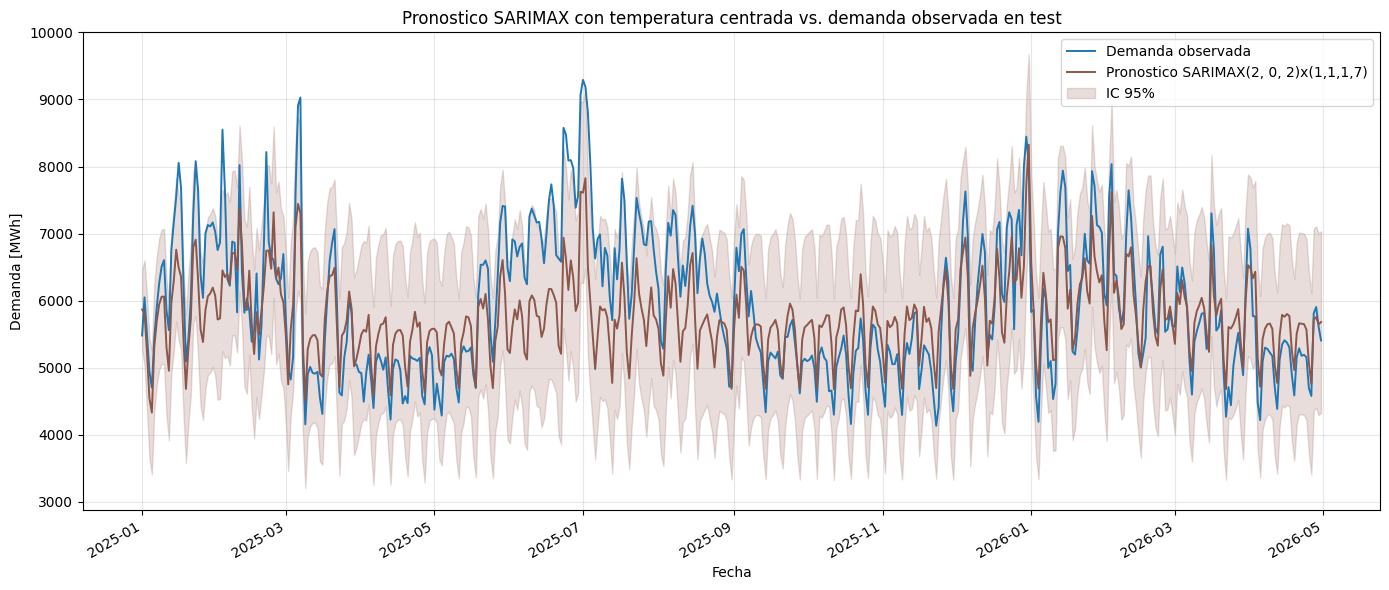

In [23]:
# Se genera el pronostico fuera de muestra con el mejor SARIMAX de esta familia.
pronostico_sarimax_centrado = mejor_resultado_sarimax_centrado.get_forecast(
    steps=len(demanda_test),
    exog=exog_test_centrada,
)
media_pronosticada_sarimax_centrado = pronostico_sarimax_centrado.predicted_mean
intervalos_pronostico_sarimax_centrado = pronostico_sarimax_centrado.conf_int()

# Se compara el pronostico SARIMAX con la serie observada en test.
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(demanda_test.index, demanda_test, label="Demanda observada", color="tab:blue", linewidth=1.4)
ax.plot(
    media_pronosticada_sarimax_centrado.index,
    media_pronosticada_sarimax_centrado,
    label=f"Pronostico SARIMAX{mejor_orden_sarimax_centrado}x(1,1,1,7)",
    color="tab:brown",
    linewidth=1.4,
)
ax.fill_between(
    intervalos_pronostico_sarimax_centrado.index,
    intervalos_pronostico_sarimax_centrado.iloc[:, 0],
    intervalos_pronostico_sarimax_centrado.iloc[:, 1],
    color="tab:brown",
    alpha=0.2,
    label="IC 95%",
)

ax.set_title("Pronostico SARIMAX con temperatura centrada vs. demanda observada en test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Demanda [MWh]")
ax.grid(True, alpha=0.3)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


En comparación con los modelos ARIMA y SARIMA previos, el SARIMAX con temperatura centrada muestra una mejora significativa. El modelo logra seguir mejor los cambios de nivel de la demanda y reproduce parte del patrón semanal, mientras que los modelos anteriores tendían a generar pronósticos más planos o excesivamente regulares. La incorporación de temperatura permite capturar variabilidad asociada a condiciones externas, aunque todavía se observan diferencias en picos extremos y períodos de alta volatilidad. 

In [24]:
# Se calculan metricas de error sobre el periodo de test para SARIMAX.
errores_sarimax_centrado = demanda_test - media_pronosticada_sarimax_centrado
metricas_sarimax_centrado = pd.Series(
    {
        "MAE": errores_sarimax_centrado.abs().mean(),
        "RMSE": (errores_sarimax_centrado.pow(2).mean()) ** 0.5,
        "MAPE": (errores_sarimax_centrado.abs().div(demanda_test).mean()) * 100,
    },
    name=f"SARIMAX{mejor_orden_sarimax_centrado}x(2,1,1,7)",
)

metricas_sarimax_centrado.to_frame(name="valor")


,valor
MAE,568.195630
RMSE,699.265482
MAPE,9.237236


## Resumen de métricas de los modelos

| Modelo | MAE | RMSE | MAPE |
|---|---:|---:|---:|
| ARIMA(2,0,2) | 881.686 | 1082.037 | 14.533 |
| SARIMA(2,0,2)x(1,0,1,7) | 839.678 | 1031.846 | 13.542 |
| SARIMAX(2,0,2)x(1,1,1,7) con temperatura | 842.152 | 1023.075 | 13.742 |
| SARIMAX(2,0,2)x(1,1,1,7) con temperatura centrada y termino cuadratico | 568.196 | 699.265 | 9.237 |

En las tres métricas el mejor desempeño corresponde al SARIMAX(2,0,2)x(1,1,1,7) con temperatura centrada y termino cuadratico, con una mejora marcada respecto de ARIMA, SARIMA y SARIMAX lineal.


El análisis muestra que la demanda diaria de GBA tiene dependencia temporal, estructura semanal y una relación relevante con la temperatura. El ARIMA(2,0,2) sirve como modelo base no estacional, pero su pronóstico tiende a estabilizarse alrededor de un nivel medio y no logra capturar la dinámica observada. La incorporación de estacionalidad semanal mediante SARIMA mejora el ajuste, aunque el pronóstico continúa siendo demasiado regular.

Los modelos SARIMAX incorporan información externa de temperatura. El modelo con temperatura lineal mejora levemente las métricas respecto del SARIMA, pero el salto más importante se observa al incluir temperatura centrada y su término cuadrático. Este último modelo reduce el MAPE de 14.53% en ARIMA a 9.24%, y también disminuye de forma marcada el MAE y el RMSE. Por lo tanto, entre los modelos evaluados, el mejor candidato predictivo es el SARIMAX con $(T_c)$ y $(T_c^2)$.

Cabe remarcar que durante el ajuste de los modelos SARIMA y SARIMAX se observaron advertencias de no convergencia. Para resolver este problema se incrementó el número máximo de iteraciones del algoritmo de optimización mediante el parámetro maxiter=1000. Luego de esta modificación, todos los modelos estimados convergieron correctamente.
